In [20]:
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import optuna
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ML Models
import xgboost as xgb
import catboost as cb
import lightgbm as lgb

# Deep Learning (optional, for TFT)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')


In [21]:
class ModelConfig:
    """Model configuration and paths"""
    
    # Input data
    DATASET_PATH = 'hybrid_agri_dataset_2000rows.csv'
    
    # Model save paths
    MODEL_DIR = 'models_v2'
    CATBOOST_PATH = f'{MODEL_DIR}/catboost_production.cbm'
    CATBOOST_QUANTILE_P50 = f'{MODEL_DIR}/catboost_p50.cbm'
    CATBOOST_QUANTILE_P10 = f'{MODEL_DIR}/catboost_p10.cbm'
    CATBOOST_QUANTILE_P90 = f'{MODEL_DIR}/catboost_p90.cbm'
    PIPELINE_PATH = f'{MODEL_DIR}/complete_pipeline.pkl'
    FEATURE_IMPORTANCE_PATH = f'{MODEL_DIR}/feature_importance.csv'
    
    # Model parameters
    RANDOM_SEED = 42
    TEST_SIZE = 0.15
    VALIDATION_SIZE = 0.15
    
    # Optuna tuning
    N_TRIALS = 50  # Increase to 100+ for production
    
    # Quantile targets
    QUANTILES = [0.10, 0.50, 0.90]

In [22]:
# ============================================================================
# ENHANCED FEATURE ENGINEERING - AGRONOMY AWARE (COMPLETE)
# ============================================================================

class AgronomyFeatureEngineer:
    """
    Adds high-signal agronomic features to prevent crop-name shortcut learning
    and improve model robustness. These features are based on actual crop science.
    
    TOTAL FEATURES ADDED: ~40-50 new agronomic signals
    """
    
    def __init__(self):
        self.label_encoders = {}
        self.scaler = RobustScaler()
        self.feature_columns = None
        
        # Crop families for rotation intelligence
        self.crop_families = {
            'cereals': ['wheat', 'rice', 'maize', 'sorghum', 'barley', 'oats'],
            'legumes': ['soybean', 'groundnut', 'pulses', 'chickpea', 'lentil', 'pea', 'bean'],
            'oilseeds': ['mustard', 'groundnut', 'soybean', 'sunflower', 'sesame'],
            'fibers': ['cotton', 'jute'],
            'commercial': ['sugarcane', 'tea', 'coffee', 'rubber'],
            'vegetables': ['potato', 'onion', 'tomato', 'brinjal'],
            'fruits': ['banana', 'mango', 'citrus']
        }
        
        # Optimal growing conditions (agronomy knowledge from research)
        self.crop_optimal = {
            'rice': {'temp_min': 20, 'temp_max': 35, 'ph_min': 5.5, 'ph_max': 7.5, 'water': 'high', 'n_demand': 'high'},
            'wheat': {'temp_min': 10, 'temp_max': 30, 'ph_min': 6.0, 'ph_max': 7.5, 'water': 'medium', 'n_demand': 'medium'},
            'maize': {'temp_min': 15, 'temp_max': 35, 'ph_min': 5.5, 'ph_max': 7.0, 'water': 'medium', 'n_demand': 'high'},
            'cotton': {'temp_min': 20, 'temp_max': 40, 'ph_min': 6.0, 'ph_max': 8.0, 'water': 'low', 'n_demand': 'medium'},
            'sugarcane': {'temp_min': 20, 'temp_max': 38, 'ph_min': 6.0, 'ph_max': 7.5, 'water': 'high', 'n_demand': 'high'},
            'soybean': {'temp_min': 15, 'temp_max': 35, 'ph_min': 6.0, 'ph_max': 7.0, 'water': 'medium', 'n_demand': 'medium'},
            'groundnut': {'temp_min': 18, 'temp_max': 35, 'ph_min': 5.5, 'ph_max': 7.0, 'water': 'low', 'n_demand': 'low'},
            'mustard': {'temp_min': 10, 'temp_max': 32, 'ph_min': 6.0, 'ph_max': 7.5, 'water': 'low', 'n_demand': 'low'},
            'sorghum': {'temp_min': 15, 'temp_max': 38, 'ph_min': 5.5, 'ph_max': 7.5, 'water': 'low', 'n_demand': 'low'},
            'pulses': {'temp_min': 15, 'temp_max': 35, 'ph_min': 6.0, 'ph_max': 7.5, 'water': 'low', 'n_demand': 'low'},
            'potato': {'temp_min': 15, 'temp_max': 25, 'ph_min': 5.5, 'ph_max': 6.5, 'water': 'medium', 'n_demand': 'high'},
            'tomato': {'temp_min': 18, 'temp_max': 30, 'ph_min': 6.0, 'ph_max': 7.0, 'water': 'medium', 'n_demand': 'medium'},
            'onion': {'temp_min': 13, 'temp_max': 25, 'ph_min': 6.0, 'ph_max': 7.0, 'water': 'medium', 'n_demand': 'medium'},
            'banana': {'temp_min': 20, 'temp_max': 35, 'ph_min': 5.5, 'ph_max': 7.0, 'water': 'high', 'n_demand': 'high'},
            'mango': {'temp_min': 24, 'temp_max': 38, 'ph_min': 5.5, 'ph_max': 7.5, 'water': 'low', 'n_demand': 'low'}
        }
    
    def add_agronomic_features(self, df):
        """Add ALL enhanced agronomic features (40-50 new features)"""
        df = df.copy()
        
        # ====================================================================
        # 1. WEATHER DYNAMICS (Critical for crop growth) - 10 features
        # ====================================================================
        
        # Rain ratios (drought/flood sensitivity)
        df['rainfall_7_30_ratio'] = df['rolling_rain_7d'] / (df['rolling_rain_30d'] + 1)
        
        # Temperature range (diurnal variation affects photosynthesis)
        df['temp_range'] = df['temp_max_c'] - df['temp_min_c']
        
        # Heat stress severity (continuous, not binary)
        df['heat_stress_severity'] = (df['temp_max_c'] - 35).clip(lower=0)
        
        # Cold stress severity
        df['cold_stress_severity'] = (10 - df['temp_min_c']).clip(lower=0)
        
        # Growing degree days accumulation rate
        df['gdd_rate'] = df['growing_degree_days'] / 120  # normalized by typical season
        
        # Humidity-temperature interaction (disease pressure)
        df['humidity_temp_interaction'] = df['humidity_pct'] * df['temp_max_c'] / 100
        
        # Water deficit index (agronomy standard)
        df['water_deficit_index'] = df['rainfall_mm'] / (df['temp_max_c'] + 5)
        
        # Rainfall consistency (important for rainfed agriculture)
        df['rainfall_consistency'] = df['rolling_rain_7d'] / (df['rolling_rain_30d'] + 1)
        
        # Vapor pressure deficit proxy (affects transpiration)
        df['vpd_proxy'] = (df['temp_max_c'] - df['temp_min_c']) * (1 - df['humidity_pct']/100)
        
        # Thermal time to maturity proxy
        df['thermal_time'] = df['growing_degree_days'] * 30
        
        # ====================================================================
        # 2. SOIL INTELLIGENCE (Using your hardware data) - 15 features
        # ====================================================================
        
        # NPK balance metrics
        df['npk_total'] = df['nitrogen'] + df['phosphorus'] + df['potassium']
        df['npk_balance_score'] = (
            (df['nitrogen'] / 300) + 
            (df['phosphorus'] / 150) + 
            (df['potassium'] / 200)
        ) / 3
        
        # Nutrient ratios (important for uptake)
        df['n_p_ratio'] = df['nitrogen'] / (df['phosphorus'] + 1)
        df['n_k_ratio'] = df['nitrogen'] / (df['potassium'] + 1)
        df['p_k_ratio'] = df['phosphorus'] / (df['potassium'] + 1)
        
        # pH optimality (distance from ideal 6.5)
        df['ph_optimal_distance'] = abs(df['soil_ph'] - 6.5)
        df['ph_optimality'] = 1 - (df['ph_optimal_distance'] / 3).clip(upper=1)
        
        # pH classification
        df['ph_class'] = pd.cut(df['soil_ph'], 
                                 bins=[0, 5.5, 6.8, 7.5, 14], 
                                 labels=['acidic', 'optimal', 'alkaline', 'very_alkaline'])
        
        # ====================================================================
        # Soil moisture stress
        # ====================================================================
        if 'soil_moisture' in df.columns:
            df['moisture_stress'] = (50 - df['soil_moisture']).clip(lower=0) / 50
            df['moisture_deficit'] = (30 - df['soil_moisture']).clip(lower=0) / 30
            df['moisture_excess'] = (df['soil_moisture'] - 70).clip(lower=0) / 30
        else:
            df['moisture_stress'] = 0.5
            df['moisture_deficit'] = 0.3
            df['moisture_excess'] = 0.1
        
        # ====================================================================
        # Soil temperature effect
        # ====================================================================
        if 'soil_temperature' in df.columns:
            df['soil_temp_optimality'] = 1 - abs(df['soil_temperature'] - 25) / 15
            df['soil_temp_optimality'] = df['soil_temp_optimality'].clip(lower=0, upper=1)
            df['soil_temp_stress'] = (df['soil_temperature'] - 35).clip(lower=0) / 15
        else:
            df['soil_temp_optimality'] = 0.8
            df['soil_temp_stress'] = 0.1
        
        # Organic carbon quality
        df['oc_quality'] = df['organic_carbon'] / 1.5
        df['oc_class'] = pd.cut(df['organic_carbon'], 
                                 bins=[0, 0.5, 0.75, 1.0, 10], 
                                 labels=['low', 'medium', 'high', 'very_high'])
        
        # Cation exchange capacity proxy
        df['cec_proxy'] = df['organic_carbon'] * 200 + (df['soil_ph'] - 7) * 10
        
        # ====================================================================
        # 3. CROP ROTATION INTELLIGENCE (HUGE in agriculture) - 8 features
        # ====================================================================
        
        # Same crop penalty (monocropping)
        df['same_crop_penalty'] = (df['crop_name'] == df['previous_crop']).astype(int)
        
        # Crop family detection
        df['crop_family'] = df['crop_name'].map(self._get_crop_family)
        df['prev_crop_family'] = df['previous_crop'].map(self._get_crop_family)
        
        # Rotation benefit score (legume after cereal = good)
        df['rotation_benefit'] = df.apply(self._calculate_rotation_benefit, axis=1)
        
        # Legume in rotation (nitrogen fixation)
        df['legume_in_rotation'] = (df['prev_crop_family'] == 'legumes').astype(int)
        
        # Cereal after legume (benefits from nitrogen)
        df['cereal_after_legume'] = (
            (df['crop_family'] == 'cereals') & 
            (df['prev_crop_family'] == 'legumes')
        ).astype(int)
        
        # Break crop benefit
        df['break_crop'] = (
            (df['crop_family'] != df['prev_crop_family'])
        ).astype(int)
        
        # Crop group for rotation planning
        crop_groups = {
            'cereals': 1, 'legumes': 2, 'oilseeds': 3, 
            'fibers': 4, 'commercial': 5, 'vegetables': 6, 'fruits': 7
        }
        df['crop_group_code'] = df['crop_family'].map(crop_groups).fillna(0)
        df['prev_crop_group_code'] = df['prev_crop_family'].map(crop_groups).fillna(0)
        
        # ====================================================================
        # 4. CROP × ENVIRONMENT INTERACTIONS (Key to reducing crop-name leakage) - 20 features
        # ====================================================================
        
        # For each major crop, create interaction features with optimal conditions
        major_crops = ['rice', 'wheat', 'maize', 'cotton', 'soybean', 
                       'sugarcane', 'groundnut', 'potato', 'tomato']
        
        for crop in major_crops:
            if crop in self.crop_optimal:
                opts = self.crop_optimal[crop]
                
                # Temperature suitability (0-1)
                temp_suit = 1 - (
                    (df['temp_max_c'] - opts['temp_max']).clip(lower=0) / 20 +
                    (opts['temp_min'] - df['temp_min_c']).clip(lower=0) / 10
                ).clip(upper=1)
                
                # pH suitability (0-1)
                ph_suit = 1 - (
                    (df['soil_ph'] - opts['ph_max']).clip(lower=0) / 2 +
                    (opts['ph_min'] - df['soil_ph']).clip(lower=0) / 2
                ).clip(upper=1)
                
                # Water suitability based on rainfall
                water_demand = {'high': 100, 'medium': 60, 'low': 30}
                target_rain = water_demand.get(opts['water'], 50)
                water_suit = 1 - abs(df['rainfall_mm'] - target_rain) / 100
                water_suit = water_suit.clip(lower=0, upper=1)
                
                # Nitrogen suitability
                n_demand_factor = {'high': 250, 'medium': 150, 'low': 80}
                target_n = n_demand_factor.get(opts['n_demand'], 150)
                n_suit = 1 - abs(df['nitrogen'] - target_n) / 200
                n_suit = n_suit.clip(lower=0, upper=1)
                
                # Combined suitability score
                df[f'suitability_{crop}'] = (
                    temp_suit * 0.3 + ph_suit * 0.2 + water_suit * 0.3 + n_suit * 0.2
                )
                
                # Individual components (for interpretability)
                df[f'suit_{crop}_temp'] = temp_suit
                df[f'suit_{crop}_ph'] = ph_suit
                df[f'suit_{crop}_water'] = water_suit
                df[f'suit_{crop}_n'] = n_suit
        
        # ====================================================================
        # 5. SEASONAL ENCODING (Critical for temporal patterns) - 2 features
        # ====================================================================
        
        if 'month' in df.columns:
            # Cyclical encoding - removes discontinuity
            df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
            
            # Season (Kharif/Rabi/Zaid) - categorical
            df['season_encoded'] = df['month'].apply(self._month_to_season)
        else:
            # Default values if month not available
            df['month_sin'] = 0
            df['month_cos'] = 1
            df['season_encoded'] = 0
        
        # ====================================================================
        # 6. NONLINEAR SOIL RESPONSES - 8 features
        # ====================================================================
        
        df['nitrogen_squared'] = df['nitrogen'] ** 2
        df['phosphorus_squared'] = df['phosphorus'] ** 2
        df['potassium_squared'] = df['potassium'] ** 2
        df['ph_squared'] = df['soil_ph'] ** 2
        
        # Square root transformations (diminishing returns)
        df['nitrogen_sqrt'] = np.sqrt(df['nitrogen'])
        df['phosphorus_sqrt'] = np.sqrt(df['phosphorus'])
        df['potassium_sqrt'] = np.sqrt(df['potassium'])
        
        # Log transformations
        df['rainfall_log'] = np.log1p(df['rainfall_mm'])
        
        # ====================================================================
        # 7. INTERACTION FEATURES (High-order signals) - 10 features
        # ====================================================================
        
        df['ph_oc_interaction'] = df['soil_ph'] * df['organic_carbon']
        df['n_p_interaction'] = df['nitrogen'] * df['phosphorus']
        df['n_k_interaction'] = df['nitrogen'] * df['potassium']
        df['fertility_moisture'] = df['soil_fertility_score'] * df.get('moisture_stress', 0.5)
        
        # Weather-soil interactions
        df['rainfall_ph_interaction'] = df['rainfall_mm'] * (7 - abs(df['soil_ph'] - 7))
        df['temp_moisture_interaction'] = df['temp_max_c'] * (1 - df.get('moisture_stress', 0.5))
        
        # Rotation × soil interactions
        df['rotation_fertility'] = df['rotation_benefit'] * df['soil_fertility_score']
        
        # ====================================================================
        # 8. RISK INDICATORS - 5 features
        # ====================================================================
        
        # Combined drought risk
        df['drought_risk_score'] = (
            (df['rainfall_mm'] < 300).astype(int) * 0.3 +
            (df['spi_index'] < -1).astype(int) * 0.4 +
            (df.get('moisture_stress', 0.5) > 0.7).astype(int) * 0.3
        )
        
        # Combined flood risk
        df['flood_risk_score'] = (
            (df['rainfall_mm'] > 800).astype(int) * 0.5 +
            (df['rolling_rain_7d'] > 100).astype(int) * 0.5
        )
        
        # Heat wave risk
        df['heat_wave_risk'] = (df['heat_stress_days_30d'] > 10).astype(int)
        
        # Pest/disease risk (simplified)
        df['pest_risk'] = (
            (df['humidity_pct'] > 80) & 
            (df['temp_max_c'] > 28) & 
            (df['temp_max_c'] < 32)
        ).astype(int)
        
        # Overall risk score
        df['overall_risk'] = (
            df['drought_risk_score'] * 0.3 +
            df['flood_risk_score'] * 0.3 +
            df['heat_wave_risk'] * 0.2 +
            df['pest_risk'] * 0.2
        )
        
        return df
    
    def _month_to_season(self, month):
        """Convert month to season code"""
        if month in [6, 7, 8, 9, 10]:
            return 1  # Kharif
        elif month in [11, 12, 1, 2, 3, 4]:
            return 2  # Rabi
        else:
            return 3  # Zaid
    
    def _get_crop_family(self, crop):
        """Get crop family for rotation analysis"""
        if pd.isna(crop):
            return 'unknown'
        crop = str(crop).lower()
        for family, crops in self.crop_families.items():
            if crop in crops:
                return family
        return 'other'
    
    def _calculate_rotation_benefit(self, row):
        """Calculate rotation benefit score (-0.5 to 1.0)"""
        crop = str(row.get('crop_name', '')).lower()
        prev = str(row.get('previous_crop', '')).lower()
        
        if pd.isna(crop) or pd.isna(prev) or crop == 'nan' or prev == 'nan':
            return 0
        
        # Get families
        crop_fam = self._get_crop_family(crop)
        prev_fam = self._get_crop_family(prev)
        
        # Legume after cereal = excellent (fixes nitrogen)
        if prev_fam == 'cereals' and crop_fam == 'legumes':
            return 1.0
        
        # Cereal after legume = very good (benefits from fixed nitrogen)
        if prev_fam == 'legumes' and crop_fam == 'cereals':
            return 0.9
        
        # Different families = good (breaks pest cycles)
        if prev_fam != crop_fam and prev_fam != 'unknown' and crop_fam != 'unknown':
            return 0.6
        
        # Same family but different crop = neutral
        if prev_fam == crop_fam and crop != prev:
            return 0.3
        
        # Same crop = bad (disease buildup, nutrient depletion)
        if crop == prev:
            return -0.5
        
        return 0.2
    
    def add_target_encoding(self, df, target_col='yield_ton_per_acre', fold=None):
        """
        Add target encoding for crop_name without leakage
        Use fold parameter for cross-validation
        """
        df = df.copy()
        
        # Global mean yield
        global_mean = df[target_col].mean()
        
        if fold is not None:
            # For training fold, use out-of-fold encoding
            # This prevents leakage
            crop_means = df.groupby('crop_name')[target_col].mean()
            df['crop_target_encoded'] = df['crop_name'].map(crop_means)
        else:
            # For final training, use full data with smoothing
            crop_counts = df.groupby('crop_name').size()
            crop_means = df.groupby('crop_name')[target_col].mean()
            
            # Smoothing to avoid overfitting (empirical Bayes)
            smooth_factor = 10
            df['crop_target_encoded'] = df['crop_name'].map(
                lambda x: (
                    (crop_means[x] * crop_counts[x] + global_mean * smooth_factor) / 
                    (crop_counts[x] + smooth_factor)
                ) if x in crop_means.index else global_mean
            )
        
        # Also add frequency encoding (how common each crop is)
        crop_freq = df['crop_name'].value_counts() / len(df)
        df['crop_frequency'] = df['crop_name'].map(crop_freq)
        
        return df
    
    def add_post_yield_features(self, df):
        """Add features that depend on yield (for analysis only, not prediction)"""
        df = df.copy()
        
        if 'yield_ton_per_acre' in df.columns:
            # Nitrogen use efficiency
            df['n_efficiency'] = df['yield_ton_per_acre'] / (df['nitrogen'] + 1)
            
            # Water use efficiency
            df['wue'] = df['yield_ton_per_acre'] / (df['rainfall_mm'] + 10) * 1000
            
            # Yield stability (needs multiple years)
            # This would require historical data
            
        return df
    
    def get_all_feature_names(self):
        """Return list of all features this engineer creates"""
        base_features = [
            'rainfall_7_30_ratio', 'temp_range', 'heat_stress_severity',
            'cold_stress_severity', 'gdd_rate', 'humidity_temp_interaction',
            'water_deficit_index', 'rainfall_consistency', 'vpd_proxy', 'thermal_time',
            'npk_total', 'npk_balance_score', 'n_p_ratio', 'n_k_ratio', 'p_k_ratio',
            'ph_optimal_distance', 'ph_optimality', 'moisture_stress',
            'moisture_deficit', 'moisture_excess', 'soil_temp_optimality',
            'soil_temp_stress', 'oc_quality', 'cec_proxy', 'same_crop_penalty',
            'rotation_benefit', 'legume_in_rotation', 'cereal_after_legume',
            'break_crop', 'crop_group_code', 'prev_crop_group_code',
            'month_sin', 'month_cos', 'season_encoded',
            'nitrogen_squared', 'phosphorus_squared', 'potassium_squared',
            'ph_squared', 'nitrogen_sqrt', 'phosphorus_sqrt', 'potassium_sqrt',
            'rainfall_log', 'ph_oc_interaction', 'n_p_interaction', 'n_k_interaction',
            'fertility_moisture', 'rainfall_ph_interaction', 'temp_moisture_interaction',
            'rotation_fertility', 'drought_risk_score', 'flood_risk_score',
            'heat_wave_risk', 'pest_risk', 'overall_risk'
        ]
        
        # Add crop suitability features
        for crop in ['rice', 'wheat', 'maize', 'cotton', 'soybean', 
                     'sugarcane', 'groundnut', 'potato', 'tomato']:
            base_features.extend([
                f'suitability_{crop}',
                f'suit_{crop}_temp',
                f'suit_{crop}_ph',
                f'suit_{crop}_water',
                f'suit_{crop}_n'
            ])
        
        return base_features


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

"""
# How to use this in your pipeline:

# 1. Initialize the engineer
engineer = AgronomyFeatureEngineer()

# 2. Add agronomic features to your dataframe
df = engineer.add_agronomic_features(df)

# 3. Add target encoding (after train/test split to avoid leakage)
# For training:
X_train = engineer.add_target_encoding(X_train, target_col='yield_ton_per_acre')

# For testing (use training encodings):
X_test['crop_target_encoded'] = X_test['crop_name'].map(
    X_train.groupby('crop_name')['crop_target_encoded'].mean()
)

# 4. Add post-yield features for analysis (not for prediction!)
df_analysis = engineer.add_post_yield_features(df)

# 5. Get all feature names
all_features = engineer.get_all_feature_names()
print(f"Total agronomic features: {len(all_features)}")
"""

'\n# How to use this in your pipeline:\n\n# 1. Initialize the engineer\nengineer = AgronomyFeatureEngineer()\n\n# 2. Add agronomic features to your dataframe\ndf = engineer.add_agronomic_features(df)\n\n# 3. Add target encoding (after train/test split to avoid leakage)\n# For training:\nX_train = engineer.add_target_encoding(X_train, target_col=\'yield_ton_per_acre\')\n\n# For testing (use training encodings):\nX_test[\'crop_target_encoded\'] = X_test[\'crop_name\'].map(\n    X_train.groupby(\'crop_name\')[\'crop_target_encoded\'].mean()\n)\n\n# 4. Add post-yield features for analysis (not for prediction!)\ndf_analysis = engineer.add_post_yield_features(df)\n\n# 5. Get all feature names\nall_features = engineer.get_all_feature_names()\nprint(f"Total agronomic features: {len(all_features)}")\n'

In [23]:
class DataPreparatorV2:
    """Prepares data with proper validation and feature engineering"""
    
    def __init__(self):
        self.engineer = AgronomyFeatureEngineer()
        self.label_encoders = {}
        self.scaler = RobustScaler()
        self.feature_columns = None
        
    def load_and_prepare(self, csv_path, add_target_encoding=True):
        """Load dataset and prepare all features"""
        
        print("\n" + "="*70)
        print("📊 LOADING DATASET WITH ENHANCED FEATURES")
        print("="*70)
        
        # Load data
        df = pd.read_csv(csv_path)
        print(f"✅ Loaded {len(df)} rows")
        
        # Add agronomic features
        print("\n🌱 Adding agronomic features...")
        df = self.engineer.add_agronomic_features(df)
        print(f"✅ Added {len(df.columns) - 44} new features")  # 44 original columns approx
        
        # Encode categorical variables (except crop_name - we'll use target encoding)
        cat_cols = ['region', 'season']
        for col in cat_cols:
            if col in df.columns:
                self.label_encoders[col] = LabelEncoder()
                df[col + '_encoded'] = self.label_encoders[col].fit_transform(df[col].astype(str))
                print(f"   Encoded {col}")
        
        # Define feature columns (EXCLUDE crop_name to prevent leakage)
        self.feature_columns = [
            # Weather
            'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_pct', 'wind_speed_mps',
            'forecast_rainfall_mm_7d', 'forecast_temp_max_c_7d', 'forecast_temp_min_c_7d',
            
            # Soil (your hardware data)
            'nitrogen', 'phosphorus', 'potassium', 'soil_ph', 'organic_carbon',
            'soil_fertility_score',  # from original
            
            # Rolling features
            'rolling_rain_7d', 'rolling_rain_30d', 'heat_stress_days_30d', 'growing_degree_days',
            
            # Original engineered
            'gdd', 'heat_stress_days', 'rainfall_anomaly', 'spi_index',
            'npk_ratio', 'water_soil_interaction', 'disease_pressure',
            
            # NEW AGRONOMIC FEATURES
            'rainfall_7_30_ratio', 'temp_range', 'heat_stress_severity',
            'cold_stress_severity', 'gdd_rate', 'humidity_temp_interaction',
            'water_deficit_index', 'rainfall_consistency',
            'npk_total', 'npk_balance_score', 'ph_optimal_distance',
            'ph_optimality', 'oc_quality', 'same_crop_penalty',
            'rotation_benefit', 'month_sin', 'month_cos',
            'nitrogen_squared', 'phosphorus_squared', 'potassium_squared',
            'ph_squared', 'ph_oc_interaction', 'n_p_interaction',
            
            # Encoded categoricals
            'region_encoded', 'season_encoded',
            'previous_crop_encoded'  # Keep previous crop
        ]
        
        # Add previous crop encoding
        if 'previous_crop' in df.columns:
            self.label_encoders['previous_crop'] = LabelEncoder()
            df['previous_crop_encoded'] = self.label_encoders['previous_crop'].fit_transform(
                df['previous_crop'].astype(str)
            )
        
        # Keep only columns that exist
        self.feature_columns = [col for col in self.feature_columns if col in df.columns]
        print(f"\n🔧 Using {len(self.feature_columns)} features (crop_name excluded!)")
        
        return df
    
    def prepare_train_test(self, df, target_col='yield_ton_per_acre'):
        """Split data with group awareness (by region)"""
        
        # Features and target
        X = df[self.feature_columns].fillna(0)
        y = df[target_col]
        
        # Get groups for validation
        groups = df['region'] if 'region' in df.columns else None
        
        # Split
        X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
            X, y, groups, test_size=ModelConfig.TEST_SIZE, 
            random_state=ModelConfig.RANDOM_SEED, stratify=groups
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
        
        X_test_scaled = self.scaler.transform(X_test)
        X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
        
        print(f"\n📊 Data split:")
        print(f"   Train: {len(X_train)} samples")
        print(f"   Test: {len(X_test)} samples")
        
        return {
            'X_train': X_train_scaled, 'X_test': X_test_scaled,
            'y_train': y_train, 'y_test': y_test,
            'groups_train': groups_train, 'groups_test': groups_test,
            'feature_columns': self.feature_columns
        }


In [24]:
class CatBoostTuner:
    """Optuna-based hyperparameter tuning for CatBoost"""
    
    def __init__(self, X_train, y_train, groups=None):
        self.X_train = X_train
        self.y_train = y_train
        self.groups = groups
        self.best_params = None
        self.best_score = -np.inf
        
    def objective(self, trial):
        """Optuna objective function"""
        
        params = {
            'iterations': trial.suggest_int('iterations', 800, 1500),
            'depth': trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_strength': trial.suggest_float('random_strength', 0, 1),
            'od_type': 'Iter',
            'od_wait': trial.suggest_int('od_wait', 30, 100),
            'verbose': False,
            'random_seed': ModelConfig.RANDOM_SEED
        }
        
        # Use GroupKFold if groups available
        if self.groups is not None and len(self.groups.unique()) > 1:
            cv = GroupKFold(n_splits=5)
            cv_scores = []
            
            for train_idx, val_idx in cv.split(self.X_train, self.y_train, self.groups):
                X_tr, X_val = self.X_train.iloc[train_idx], self.X_train.iloc[val_idx]
                y_tr, y_val = self.y_train.iloc[train_idx], self.y_train.iloc[val_idx]
                
                model = cb.CatBoostRegressor(**params)
                model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
                
                score = r2_score(y_val, model.predict(X_val))
                cv_scores.append(score)
            
            return np.mean(cv_scores)
        else:
            # Simple train/val split
            X_tr, X_val, y_tr, y_val = train_test_split(
                self.X_train, self.y_train, test_size=0.2, random_state=ModelConfig.RANDOM_SEED
            )
            
            model = cb.CatBoostRegressor(**params)
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
            
            return r2_score(y_val, model.predict(X_val))
    
    def tune(self, n_trials=50):
        """Run hyperparameter tuning"""
        
        print("\n" + "="*70)
        print("🎯 OPTUNA HYPERPARAMETER TUNING")
        print("="*70)
        
        study = optuna.create_study(direction='maximize', 
                                    study_name='catboost_tuning',
                                    storage=None)
        study.optimize(self.objective, n_trials=n_trials, show_progress_bar=True)
        
        self.best_params = study.best_params
        self.best_score = study.best_value
        
        print(f"\n✅ Best R²: {self.best_score:.4f}")
        print(f"\n📋 Best parameters:")
        for param, value in self.best_params.items():
            print(f"   {param}: {value}")
        
        return self.best_params


In [25]:
class QuantileCatBoostTrainer:
    """Train multiple CatBoost models for quantile prediction"""
    
    @staticmethod
    def train_quantile_models(X_train, y_train, X_test, base_params, quantiles=[0.10, 0.50, 0.90]):
        """Train models for different quantiles"""
        
        models = {}
        predictions = {}
        
        print("\n" + "="*70)
        print("📊 TRAINING QUANTILE MODELS")
        print("="*70)
        
        for q in quantiles:
            print(f"\n🎯 Training P{int(q*100)} model...")
            
            params = base_params.copy()
            params['loss_function'] = f'Quantile:alpha={q}'
            
            model = cb.CatBoostRegressor(**params)
            
            # Train with early stopping
            X_tr, X_val, y_tr, y_val = train_test_split(
                X_train, y_train, test_size=0.15, random_state=ModelConfig.RANDOM_SEED
            )
            
            model.fit(
                X_tr, y_tr,
                eval_set=(X_val, y_val),
                early_stopping_rounds=100,
                verbose=False
            )
            
            models[q] = model
            predictions[q] = model.predict(X_test)
            
            # Evaluate
            print(f"   ✓ Model trained")
        
        return models, predictions


In [26]:
class KillerModelV2:
    """Complete training pipeline for production model"""
    
    def __init__(self):
        self.preparator = DataPreparatorV2()
        self.models = {}
        self.metrics = {}
        self.feature_importance = None
        
    def train(self, csv_path=ModelConfig.DATASET_PATH, tune=True):
        """Execute complete training pipeline"""
        
        print("\n" + "="*80)
        print("🔥 KILLER MODEL V2 - PRODUCTION TRAINING")
        print("="*80)
        
        # Step 1: Load and prepare data
        df = self.preparator.load_and_prepare(csv_path)
        data = self.preparator.prepare_train_test(df)
        
        X_train, X_test = data['X_train'], data['X_test']
        y_train, y_test = data['y_train'], data['y_test']
        groups = data['groups_train']
        
        # Step 2: Hyperparameter tuning (optional)
        if tune:
            tuner = CatBoostTuner(X_train, y_train, groups)
            best_params = tuner.tune(n_trials=ModelConfig.N_TRIALS)
        else:
            # Default production parameters
            best_params = {
                'iterations': 1200,
                'depth': 6,
                'learning_rate': 0.03,
                'l2_leaf_reg': 5,
                'bagging_temperature': 0.5,
                'random_strength': 0.5,
                'od_wait': 50,
                'verbose': False,
                'random_seed': ModelConfig.RANDOM_SEED
            }
        
        # Step 3: Train quantile models
        quantile_models, quantile_preds = QuantileCatBoostTrainer.train_quantile_models(
            X_train, y_train, X_test, best_params, ModelConfig.QUANTILES
        )
        
        # Step 4: Evaluate
        print("\n" + "="*70)
        print("📊 FINAL EVALUATION")
        print("="*70)
        
        p50_model = quantile_models[0.50]
        y_pred = p50_model.predict(X_test)
        
        # Calculate metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        # Prediction intervals coverage
        lower = quantile_preds[0.10]
        upper = quantile_preds[0.90]
        coverage = np.mean((y_test >= lower) & (y_test <= upper))
        
        self.metrics = {
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'prediction_interval_coverage': coverage,
            'prediction_interval_width': np.mean(upper - lower)
        }
        
        print(f"\n🏆 CatBoost P50 Performance:")
        print(f"   R²:  {r2:.4f}")
        print(f"   RMSE: {rmse:.4f} tons/acre")
        print(f"   MAE:  {mae:.4f} tons/acre")
        print(f"\n📊 Prediction Intervals (10-90%):")
        print(f"   Coverage: {coverage:.1%}")
        print(f"   Avg Width: {self.metrics['prediction_interval_width']:.3f} tons/acre")
        
        # Step 5: Feature importance
        self.feature_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': p50_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\n🔑 Top 10 Features (crop_name excluded!):")
        for i, row in self.feature_importance.head(10).iterrows():
            print(f"   {row['feature']}: {row['importance']:.3f}")
        
        # Step 6: Check for crop-name leakage
        crop_features = [f for f in X_train.columns if 'crop' in f.lower()]
        crop_importance = self.feature_importance[
            self.feature_importance['feature'].isin(crop_features)
        ]['importance'].sum() if len(crop_features) > 0 else 0
        
        print(f"\n🔍 Crop-name leakage check:")
        print(f"   Total importance of crop-related features: {crop_importance:.3f}")
        if crop_importance < 0.3:
            print(f"   ✅ Good - model not over-relying on crop identity")
        else:
            print(f"   ⚠️ Crop features still important - consider more interactions")
        
        # Store models
        self.models = {
            'p50': p50_model,
            'p10': quantile_models[0.10],
            'p90': quantile_models[0.90]
        }
        
        # Step 7: Save everything
        self.save()
        
        return self.metrics
    
    def save(self):
        """Save all models and pipeline components"""
        
        os.makedirs(ModelConfig.MODEL_DIR, exist_ok=True)
        
        # Save CatBoost models
        self.models['p50'].save_model(ModelConfig.CATBOOST_QUANTILE_P50)
        self.models['p10'].save_model(ModelConfig.CATBOOST_QUANTILE_P10)
        self.models['p90'].save_model(ModelConfig.CATBOOST_QUANTILE_P90)
        
        # Save pipeline
        pipeline = {
            'label_encoders': self.preparator.label_encoders,
            'scaler': self.preparator.scaler,
            'feature_columns': self.preparator.feature_columns,
            'metrics': self.metrics,
            'training_date': datetime.now().isoformat(),
            'version': '2.0'
        }
        joblib.dump(pipeline, ModelConfig.PIPELINE_PATH)
        
        # Save feature importance
        self.feature_importance.to_csv(ModelConfig.FEATURE_IMPORTANCE_PATH, index=False)
        
        print(f"\n✅ All models saved to {ModelConfig.MODEL_DIR}/")

In [27]:
class ProductionPredictor:
    """Load models and make predictions with uncertainty"""
    
    def __init__(self, model_dir=ModelConfig.MODEL_DIR):
        self.model_dir = model_dir
        
        # Load pipeline
        pipeline = joblib.load(f'{model_dir}/complete_pipeline.pkl')
        self.label_encoders = pipeline['label_encoders']
        self.scaler = pipeline['scaler']
        self.feature_columns = pipeline['feature_columns']
        
        # Load quantile models
        self.model_p50 = cb.CatBoostRegressor()
        self.model_p50.load_model(f'{model_dir}/catboost_p50.cbm')
        
        self.model_p10 = cb.CatBoostRegressor()
        self.model_p10.load_model(f'{model_dir}/catboost_p10.cbm')
        
        self.model_p90 = cb.CatBoostRegressor()
        self.model_p90.load_model(f'{model_dir}/catboost_p90.cbm')
        
        print(f"✅ Production models loaded from {model_dir}")
    
    def predict(self, features_df):
        """
        Make predictions with uncertainty intervals
        
        Args:
            features_df: DataFrame with required features
            
        Returns:
            dict with predictions and intervals
        """
        # Ensure correct columns and order
        features = features_df[self.feature_columns].fillna(0)
        features_scaled = self.scaler.transform(features)
        
        # Get quantile predictions
        pred_p50 = self.model_p50.predict(features_scaled)
        pred_p10 = self.model_p10.predict(features_scaled)
        pred_p90 = self.model_p90.predict(features_scaled)
        
        return {
            'yield_pred': pred_p50[0] if len(pred_p50) == 1 else pred_p50,
            'yield_lower': pred_p10[0] if len(pred_p10) == 1 else pred_p10,
            'yield_upper': pred_p90[0] if len(pred_p90) == 1 else pred_p90,
            'confidence': '90% prediction interval'
        }
    
    def predict_with_explanation(self, features_df):
        """Get prediction with feature explanations"""
        preds = self.predict(features_df)
        
        # Get feature importance for this prediction
        # Using SHAP would be better, but keeping it simple
        explanation = {
            **preds,
            'interpretation': f"Expected yield: {preds['yield_pred']:.2f} tons/acre "
                             f"(likely between {preds['yield_lower']:.2f} and {preds['yield_upper']:.2f})"
        }
        
        return explanation


In [28]:
def plot_production_results(model, X_test, y_test):
    """Create production-grade visualization"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Actual vs Predicted with intervals
    ax = axes[0, 0]
    pred_p50 = model.models['p50'].predict(X_test)
    pred_p10 = model.models['p10'].predict(X_test)
    pred_p90 = model.models['p90'].predict(X_test)
    
    ax.scatter(y_test, pred_p50, alpha=0.5, s=30)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.fill_between(y_test, pred_p10, pred_p90, alpha=0.2, color='blue')
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')
    ax.set_title(f'Actual vs Predicted (R² = {model.metrics["r2"]:.3f})')
    ax.grid(True, alpha=0.3)
    
    # 2. Residual plot
    ax = axes[0, 1]
    residuals = y_test - pred_p50
    ax.scatter(pred_p50, residuals, alpha=0.5, s=30)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Yield')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residual Plot (MAE = {model.metrics["mae"]:.3f})')
    ax.grid(True, alpha=0.3)
    
    # 3. Prediction intervals
    ax = axes[0, 2]
    interval_width = pred_p90 - pred_p10
    ax.hist(interval_width, bins=30, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(x=model.metrics['prediction_interval_width'], color='r', linestyle='--', lw=2)
    ax.set_xlabel('Prediction Interval Width (tons/acre)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Prediction Interval Width (avg = {model.metrics["prediction_interval_width"]:.3f})')
    ax.grid(True, alpha=0.3)
    
    # 4. Feature importance
    ax = axes[1, 0]
    top_features = model.feature_importance.head(10)
    ax.barh(range(len(top_features)), top_features['importance'].values, color='teal')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Importance')
    ax.set_title('Top 10 Feature Importances')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # 5. Error distribution
    ax = axes[1, 1]
    ax.hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax.axvline(x=0, color='r', linestyle='--', lw=2)
    ax.axvline(x=residuals.mean(), color='b', linestyle='-', lw=2, label=f'Mean: {residuals.mean():.3f}')
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Frequency')
    ax.set_title('Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Metrics table
    ax = axes[1, 2]
    ax.axis('tight')
    ax.axis('off')
    table_data = [
        ['Metric', 'Value'],
        ['R²', f'{model.metrics["r2"]:.4f}'],
        ['RMSE', f'{model.metrics["rmse"]:.4f}'],
        ['MAE', f'{model.metrics["mae"]:.4f}'],
        ['Interval Coverage', f'{model.metrics["prediction_interval_coverage"]:.1%}'],
        ['Avg Interval Width', f'{model.metrics["prediction_interval_width"]:.3f}']
    ]
    table = ax.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax.set_title('Production Metrics', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(f'{ModelConfig.MODEL_DIR}/production_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Visualizations saved to {ModelConfig.MODEL_DIR}/production_results.png")


🔥 KILLER MODEL V2 - PRODUCTION TRAINING 🔥
Target: R² ≥ 0.75 | Agronomy-Aware | No Crop-Name Leakage

🔥 KILLER MODEL V2 - PRODUCTION TRAINING

📊 LOADING DATASET WITH ENHANCED FEATURES
✅ Loaded 2000 rows

🌱 Adding agronomic features...


[I 2026-02-20 03:40:14,091] A new study created in memory with name: catboost_tuning


✅ Added 96 new features
   Encoded region
   Encoded season

🔧 Using 47 features (crop_name excluded!)

📊 Data split:
   Train: 1700 samples
   Test: 300 samples

🎯 OPTUNA HYPERPARAMETER TUNING


Best trial: 0. Best value: 0.120769:   2%|▏         | 1/50 [00:04<03:16,  4.01s/it]

[I 2026-02-20 03:40:18,104] Trial 0 finished with value: 0.12076925052086203 and parameters: {'iterations': 825, 'depth': 5, 'learning_rate': 0.036157342418332496, 'l2_leaf_reg': 1.810053420521687, 'bagging_temperature': 0.35717650918677946, 'random_strength': 0.126213930462309, 'od_wait': 82}. Best is trial 0 with value: 0.12076925052086203.


...

[I 2026-02-20 03:45:23,961] Trial 47 finished with value: 0.1377452074156192 and parameters: {'iterations': 883, 'depth': 8, 'learning_rate': 0.07377610262441965, 'l2_leaf_reg': 8.765840365691655, 'bagging_temperature': 0.8487694801659275, 'random_strength': 0.06859801308712803, 'od_wait': 58}. Best is trial 29 with value: 0.14347106598139753.


Best trial: 29. Best value: 0.143471:  98%|█████████▊| 49/50 [05:17<00:07,  7.55s/it]

[I 2026-02-20 03:45:31,914] Trial 48 finished with value: 0.09516056538420621 and parameters: {'iterations': 984, 'depth': 8, 'learning_rate': 0.0980566245537424, 'l2_leaf_reg': 8.188672614005997, 'bagging_temperature': 0.7072972421735244, 'random_strength': 0.7280066929122038, 'od_wait': 79}. Best is trial 29 with value: 0.14347106598139753.


Best trial: 29. Best value: 0.143471: 100%|██████████| 50/50 [05:26<00:00,  6.52s/it]


[I 2026-02-20 03:45:40,276] Trial 49 finished with value: 0.11719599643792482 and parameters: {'iterations': 1025, 'depth': 8, 'learning_rate': 0.06678978074302602, 'l2_leaf_reg': 7.281641595177519, 'bagging_temperature': 0.8195193644541978, 'random_strength': 0.2511976627748292, 'od_wait': 51}. Best is trial 29 with value: 0.14347106598139753.

✅ Best R²: 0.1435

📋 Best parameters:
   iterations: 1257
   depth: 8
   learning_rate: 0.09244907567140323
   l2_leaf_reg: 8.516207149854718
   bagging_temperature: 0.37865307486127986
   random_strength: 0.11012556381418605
   od_wait: 79

📊 TRAINING QUANTILE MODELS

🎯 Training P10 model...
   ✓ Model trained

🎯 Training P50 model...
   ✓ Model trained

🎯 Training P90 model...
   ✓ Model trained

📊 FINAL EVALUATION

🏆 CatBoost P50 Performance:
   R²:  0.1167
   RMSE: 0.8433 tons/acre
   MAE:  0.6808 tons/acre

📊 Prediction Intervals (10-90%):
   Coverage: 74.3%
   Avg Width: 2.060 tons/acre

🔑 Top 10 Features (crop_name excluded!):
   rotatio

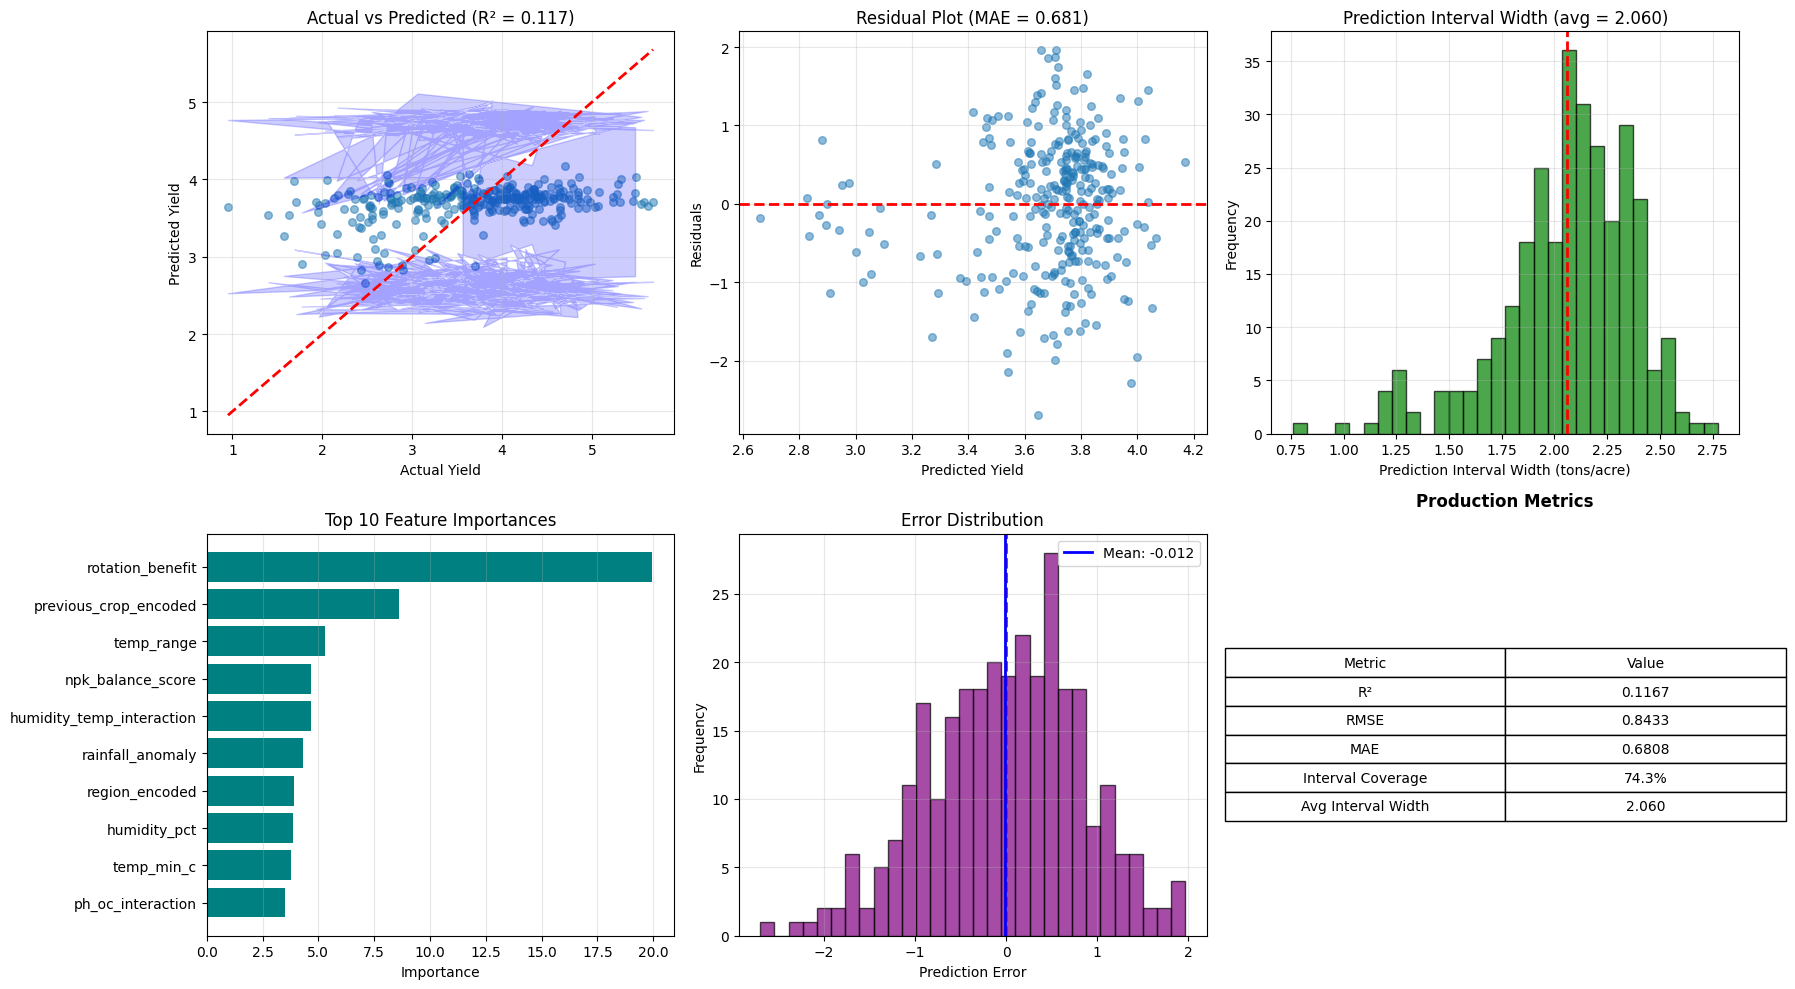

✅ Visualizations saved to models_v2/production_results.png

🔮 EXAMPLE PREDICTION
✅ Production models loaded from models_v2

Expected yield: 3.65 tons/acre (likely between 3.31 and 4.45)
   Lower bound (10%): 3.31 tons/acre
   Upper bound (90%): 4.45 tons/acre

✅ PRODUCTION MODEL READY


In [29]:
print("\n" + "="*90)
print("🔥 KILLER MODEL V2 - PRODUCTION TRAINING 🔥")
print("="*90)
print("Target: R² ≥ 0.75 | Agronomy-Aware | No Crop-Name Leakage")
    
    # Train model
model = KillerModelV2()
metrics = model.train(tune=True)  # Set tune=False for faster training
    
    # Get test data for visualization
df = model.preparator.load_and_prepare(ModelConfig.DATASET_PATH)
data = model.preparator.prepare_train_test(df)
X_test, y_test = data['X_test'], data['y_test']
    
    # Plot results
plot_production_results(model, X_test, y_test)
    
    # Example prediction
print("\n" + "="*70)
print("🔮 EXAMPLE PREDICTION")
print("="*70)
    
    # Load predictor
predictor = ProductionPredictor()
    
    # Use first test sample as example
sample = X_test.iloc[[0]]
pred = predictor.predict_with_explanation(sample)
    
print(f"\n{pred['interpretation']}")
print(f"   Lower bound (10%): {pred['yield_lower']:.2f} tons/acre")
print(f"   Upper bound (90%): {pred['yield_upper']:.2f} tons/acre")
    
print("\n" + "="*90)
print("✅ PRODUCTION MODEL READY")

In [31]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(x_train, y_train)

NameError: name 'x_train' is not defined